Erwartete Messbereiche

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import uncertainties as uc
from uncertainties import unumpy

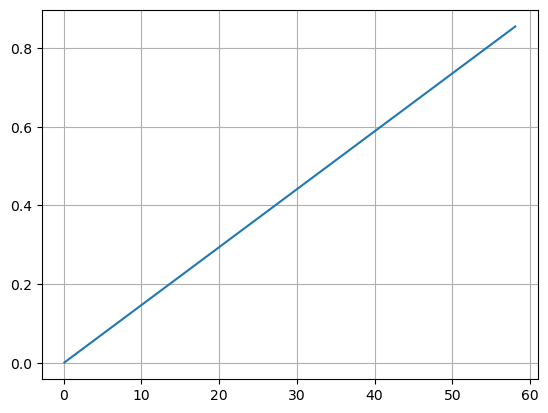

In [61]:
r_soll = 68
r_iv = 10_000_00
u = np.linspace(0.3, 58.3)
u_V = u - 0.2
i_A = u_V*(1/r_soll + 1/r_iv)

plt.plot(u_V, i_A)
plt.grid()
plt.show()

In [67]:
u_unc = u_V * 0.0005
i_unc = np.concatenate((i_A[i_A <= 0.02] * 0.003, i_A[i_A > 0.02] * 0.005))

u_meas = unumpy.uarray(u_V, u_unc)
i_meas = unumpy.uarray(i_A, i_unc)
r_meas = u_meas / (i_meas - u_meas/r_iv)
print(r_meas)

[68.0+/-0.20682798937710956 68.00000000000001+/-0.20682798937710956
 68.0+/-0.3417190064305463 68.0+/-0.34171900643054626
 68.0+/-0.3417190064305463 68.0+/-0.3417190064305463
 68.0+/-0.34171900643054626 68.00000000000001+/-0.34171900643054637
 68.0+/-0.3417190064305463 68.0+/-0.34171900643054637
 68.0+/-0.34171900643054637 68.0+/-0.3417190064305463
 68.0+/-0.34171900643054637 68.0+/-0.3417190064305463
 68.0+/-0.3417190064305463 68.00000000000001+/-0.3417190064305463
 68.0+/-0.34171900643054626 68.00000000000001+/-0.3417190064305463
 68.00000000000001+/-0.3417190064305463 68.0+/-0.34171900643054626
 68.0+/-0.3417190064305463 68.00000000000001+/-0.34171900643054637
 68.0+/-0.34171900643054626 68.0+/-0.3417190064305463
 68.00000000000001+/-0.3417190064305464 68.0+/-0.3417190064305463
 68.0+/-0.34171900643054637 68.0+/-0.34171900643054637
 68.0+/-0.3417190064305463 68.0+/-0.34171900643054626
 68.0+/-0.3417190064305463 68.00000000000001+/-0.3417190064305464
 68.0+/-0.3417190064305463 68.0+/

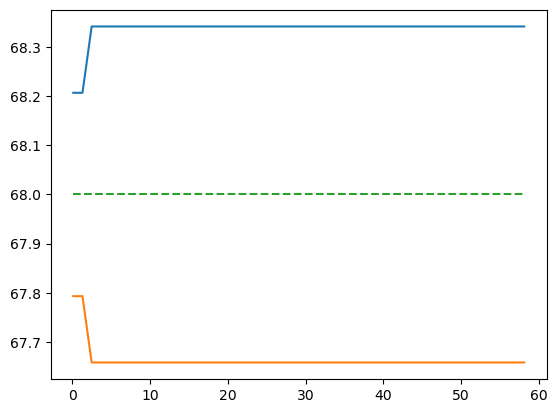

In [ ]:
r_s = np.copy(r_meas)
r_n = np.copy(r_meas)

for i in range(0, len(r_meas)):
    r_s[i] = r_meas[i].s
    r_n[i] = r_meas[i].n
    
plt.plot(u_V, r_n + r_s)
plt.plot(u_V, r_n - r_s)
plt.plot(u_V, r_n, '--')
plt.show()